In [1]:
import ctypes as ct
import MDAnalysis as mda
import MDA_unwrap_PBC as unwrap
from scipy.fft import fft, ifft, dct, idct
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# ctype data structures for rotatable bonds
class t_rotBond(ct.Structure):
    '''datatype describing a rotatable bond and its satellites'''
    _fields_ = (("bondAtomIndices", ct.c_int32*2),
                ("sat0AtomIndices", ct.c_int32*4),
                ("nSat0", ct.c_int32),
                ("sat3AtomIndices", ct.c_int32*4),
                ("nSat3", ct.c_int32),
                ("sumInertia", ct.c_double),
                ("sumLogInertia", ct.c_double),
                ("wOmegaBuffer", ct.POINTER(ct.c_double))
                )

class t_residue(ct.Structure):
    '''datatype with data and pointers for residue/molecule)'''
    _fields_ = (# constant data
                ("nAtoms", ct.c_int32),
                ("resMass", ct.c_double),
                ("nRotBonds", ct.c_int32),
                ("atomMasses", ct.POINTER(ct.c_double)),
                ("atomMassesX3", ct.POINTER(ct.c_double)),
                ("rotBonds", ct.POINTER(t_rotBond)),
                # transient data
                ("atomCrdMol", ct.POINTER(ct.c_double)),
                ("atomVelMol", ct.POINTER(ct.c_double)),
                ("inertia", ct.c_double*3),
                ("prevAxes", ct.c_double*9),
                ("angMomLab", ct.c_double*3),
                ("angMomMol", ct.c_double*3),
                ("omegaMol", ct.c_double*3),
                ("omegaLab", ct.c_double*3),
                ("COMposBuffer", ct.POINTER(ct.c_double)),
                ("COMposCurrent", ct.POINTER(ct.c_double)),
                ("COMposCorrRef", ct.POINTER(ct.c_double)),
                ("COMvelBuffer", ct.POINTER(ct.c_double)),
                ("COMvelCurrent", ct.POINTER(ct.c_double)),
                ("COMvelCorrRef", ct.POINTER(ct.c_double)),
                ("wOmegaBuffer", ct.POINTER(ct.c_double)),
                ("wOmegaCurrent", ct.POINTER(ct.c_double)),
                ("wOmegaCorrRef", ct.POINTER(ct.c_double)),
                # accumulating data
                ("sumInertia", ct.c_double*3),
                ("sumLogInertia", ct.c_double*3),
                ("totCorr",ct.POINTER(ct.c_double)),
                ("trCorr",ct.POINTER(ct.c_double)),
                ("rotCorr",ct.POINTER(ct.c_double)),
                ("rotBondCorr",ct.POINTER(ct.c_double)),
                ("propCnt", ct.c_int32),
                ("corrCnt", ct.c_int32),
                # offset in arrays above
                ("offset", ct.c_int32)
                )

class t_residueList(ct.Structure):
    '''datatype describing a list of residues (e.g., for each residue in a selection)'''
    _fields_ = (("residues", ct.POINTER(t_residue)),
                ("nResidues", ct.c_int32),
                ("totCorr",ct.POINTER(ct.c_double)),
                ("trCorr",ct.POINTER(ct.c_double)),
                ("rotCorr",ct.POINTER(ct.c_double)),
                ("rotBondCorr",ct.POINTER(ct.c_double)),
                ("inertia", ct.c_double*3),
                ("logInertia", ct.c_double*3),
                ("rotBondInertia", ct.c_double),
                ("logRotBondInertia", ct.c_double)
                )
    
class t_MDinfo(ct.Structure):
    '''datatype with data and pointers for MD simulation'''
    _fields_ = (# number of doubles in per frame in array
                ("frameSize", ct.c_int32),
                # single set of atomic coordinates for selection
                ("atomCrd", ct.POINTER(ct.c_double)),
                # number of doubles in atomVelBuffer
                ("bufferSize", ct.c_int32),
                # nCorr sets of atomic velocities for selection
                ("atomVelBuffer", ct.POINTER(ct.c_double)),
                # pointer to current set of atomic velocities in buffer
                ("atomVelCurrent", ct.POINTER(ct.c_double)),
                # pointer to first set of atomic velocities in current buffer
                ("atomVelCorrRef", ct.POINTER(ct.c_double)),
                # nCorr sets of atomic velocities for selection
                ("nCorr", ct.c_int32),
                # number of atoms in selection
                ("nAtomsSel", ct.c_int32)
                )

In [3]:
#load the shared library with C routines
clib = ct.cdll.LoadLibrary("vdos.so")

In [4]:
# allocate residues in residueList
clib.allocResidueList.argtypes = [
    # list of residues in selection
    ct.POINTER(t_residueList),
    # number of residues in selection
    ct.c_int32,
    # number of correlation times to allocate arrays
    ct.c_int32
]
clib.allocResidueList.restype = ct.c_int32

# allocate MDinfo
clib.allocMDinfo.argtypes = [
    # list of residues in selection
    ct.POINTER(t_MDinfo),
    # number of correlation times
    ct.c_int32,
    # number of atoms in selection
    ct.c_int32
]
clib.allocMDinfo.restype = ct.c_int32

# allocate all arrays needed for residue and set constant pointers
clib.allocResidue.argtypes = [
    # pointer to residue
    ct.POINTER(t_residue),
    # number of atoms in residue
    ct.c_int32,
    # # list of atomic masses for residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
    # residue mass
    ct.c_double,
    # number of atoms in selection
    # (needed for offsets in atomic velocity buffer)
    ct.c_int32,
    # number of correlation times to allocate arrays
    ct.c_int32
]
clib.allocResidue.restype = ct.c_int32

# set pointers to atom coordinates and velocities for each residue
clib.setArrayIndexOffsets.argtypes = [
    # pointer to residue list
    ct.POINTER(t_residueList),
    # pointer to MDinfo
    ct.POINTER(t_MDinfo)
]
clib.setArrayIndexOffsets.restype = ct.c_int32

#find rotatable bonds in all residues
clib.getRotBonds.argtypes = [
    # sets of residues
    ct.POINTER(t_residueList),
    # number of residues
    ct.c_int32,
    # list of atom indices for dihedrals
    np.ctypeslib.ndpointer(dtype=np.int32, ndim=2, flags='C_CONTIGUOUS'),
    # number of dihedrals
    ct.c_int32,
    # pair of atom indices indicating the first and last atom index of each residue
    np.ctypeslib.ndpointer(dtype=np.int32, ndim=2, flags='C_CONTIGUOUS'),
    # number of correlation times to allocate arrays
    ct.c_int32
]
clib.getRotBonds.restype = ct.c_int32

#process simulation time step
clib.processStep.argtypes = [
    #time step
    ct.c_int32,
    #structure to store MD atomic corrdinates and buffer of velocities
    ct.POINTER(t_MDinfo),
    #atomic coordinates for selection
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #atomic velocities for selection
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #residue list to store residue properties
    ct.POINTER(t_residueList),
    #number of correlation times to allocate arrays
    ct.c_int32
]
clib.processStep.restype = ct.c_int32

# post-processing of correlation functions
clib.postProcess.argtypes = [
    #time step
    ct.POINTER(t_residueList),
    #number of correlation times
    ct.c_int32
]
clib.postProcess.restype = ct.c_int32

In [5]:
class vdos:
    def __init__(self,sel,nCorr):
        self.sel = sel
        self.nCorr = nCorr
        self.nRes = sel.residues.n_residues
        # time and frequency axes for correlation functions and VDoS
        self.tau = np.zeros(nCorr, dtype = np.float64)
        self.wavenumber = np.zeros(nCorr, dtype = np.float64)
        # numpy arrays for average (index 0) and per residue VACF & VDoS (in 3D-2PT for each voxel)
        # -> total VACF / VDoS (1D)
        # -> translation VACF / VDoS (3D)
        # -> rotation VACF / VDoS (3D)
        # -> rotatable bonds VACF / VDoS (1D)
        self.totVACF     = np.zeros((self.nRes+1,    nCorr), dtype = np.float64)
        self.totVDoS     = np.zeros((self.nRes+1,    nCorr), dtype = np.float64)
        self.trVACF      = np.zeros((self.nRes+1, 3, nCorr), dtype = np.float64)
        self.trVDoS      = np.zeros((self.nRes+1, 3, nCorr), dtype = np.float64)
        self.rotVACF     = np.zeros((self.nRes+1, 3, nCorr), dtype = np.float64)
        self.rotVDoS     = np.zeros((self.nRes+1, 3, nCorr), dtype = np.float64)
        self.rotBondVACF = np.zeros((self.nRes+1,    nCorr), dtype = np.float64)
        self.rotBondVDoS = np.zeros((self.nRes+1,    nCorr), dtype = np.float64)
        # initialize residueList and MDinfo
        self.residueList, self.MDinfo = self.prep()
        # postProcessing flag
        self.postProcessed = False

    def prep(self):
        '''construct list of residues for selection'''
        residueList = t_residueList()
        error = clib.allocResidueList(
            ct.pointer(residueList),
            ct.c_int(self.nRes),
            ct.c_int(self.nCorr)
        )
        MDinfo = t_MDinfo()
        error = clib.allocMDinfo(
            ct.pointer(MDinfo),
            ct.c_int(self.nCorr),
            ct.c_int(self.sel.n_atoms)
        )
        r = 0
        for res in self.sel.residues:
            error = clib.allocResidue(
                ct.pointer(residueList.residues[r]),
                ct.c_int(len(res.atoms)),
                res.atoms.masses.astype(np.float64),
                ct.c_double(res.mass.astype('float64')),
                ct.c_int(self.sel.n_atoms),
                ct.c_int(self.nCorr)
            )
            if error != 0:
                print(f'ERROR reported by \'clib.allocResidue\'\n')
            r += 1
        clib.setArrayIndexOffsets(ct.pointer(residueList), ct.pointer(MDinfo))
        dihed = self.sel.intra_dihedrals.indices.astype(np.int32)
        resAtomRangeList = np.zeros((len(self.sel.residues),2), dtype = np.int32)
        i = 0
        for res in self.sel.residues:
            resAtomRangeList[i][0] = np.amin(res.atoms.indices)
            resAtomRangeList[i][1] = np.amax(res.atoms.indices)
            i += 1
        error = clib.getRotBonds(
            ct.pointer(residueList),
            ct.c_int(self.nRes),
            dihed,
            ct.c_int(len(dihed)),
            resAtomRangeList,
            self.nCorr
        )
        if error != 0:
            print(f'ERROR reported by \'clib.getRotBonds\'\n')
        return residueList, MDinfo
    
    def processStep(self,tStep,time):
        if tStep < self.nCorr:
            self.tau[tStep] = time
        error=clib.processStep(
            ct.c_int(tStep),
            ct.pointer(self.MDinfo),
            self.sel.atoms.positions.astype(np.float64),
            self.sel.atoms.velocities.astype(np.float64),
            ct.pointer(self.residueList),
            ct.c_int(self.nCorr)
        )

    def postProcess(self):
        '''post-process correlation functions'''
        if not self.postProcessed:
            clib.postProcess(ct.pointer(self.residueList), ct.c_int(self.nCorr))
            period = (self.tau[1] - self.tau[0]) * (2 * self.nCorr - 1)
            wn0 = (1.0 / period) * 33.35641
            self.wavenumber = np.arange(0,self.nCorr) * wn0
            self.totVACF[0] = self.residueList.totCorr[0:self.nCorr]
            self.symFT(self.totVACF[0], self.totVDoS[0])
            for i in range(3):
                self.trVACF[0][i] = self.residueList.trCorr[i:3*self.nCorr:3]
                self.symFT(self.trVACF[0][i], self.trVDoS[0][i])
                self.rotVACF[0][i] = self.residueList.rotCorr[i:3*self.nCorr:3]
                self.symFT(self.rotVACF[0][i], self.rotVDoS[0][i])
            self.rotBondVACF[0] = self.residueList.rotBondCorr[0:self.nCorr]
            self.symFT(self.rotBondVACF[0], self.rotBondVDoS[0])
            for i in range(1,self.nRes+1):
                self.totVACF[i] = self.residueList.residues[i-1].totCorr[0:self.nCorr]
                self.symFT(self.totVACF[i], self.totVDoS[i])
                for j in range(3):
                    self.trVACF[i][j] = self.residueList.residues[i-1].trCorr[j:3*self.nCorr:3]
                    self.symFT(self.trVACF[i][j], self.trVDoS[i][j])
                    self.rotVACF[i][j] = self.residueList.residues[i-1].rotCorr[j:3*self.nCorr:3]
                    self.symFT(self.rotVACF[i][j], self.rotVDoS[i][j])
                self.rotBondVACF[i] = self.residueList.residues[i-1].rotBondCorr[0:self.nCorr]
                self.symFT(self.rotBondVACF[i], self.rotBondVDoS[i])
            self.postProcessed = True

    def symFT(self,input,output):
        '''symmetrize, Fourier transform and return first half of spectrum'''
        data = np.array(input, dtype = np.float64)
        nData=len(data)
        tmp = np.zeros(2 * nData - 1, dtype = np.float64)
        for i in range(nData):
            tmp[i] = data[i]
        for i in range(1,nData):
            j = 2 * nData - i - 1
            tmp[j] = tmp[i]
        tmp = fft(tmp)
        for i in range(nData):
            output[i] = tmp[i].real
    
    def outputGeometry(self,outputFileName):
        totMass = 0.0
        for i in range(self.nRes):
            totMass += self.residueList.residues[i].resMass
        averMass = totMass / self.nRes
        averInertia = self.residueList.inertia[0:3]
        averLogInertia = self.residueList.logInertia[0:3]
        averRotBondCount = 0
        for i in range(self.nRes):
            averRotBondCount += self.residueList.residues[i].nRotBonds
        averRotBondCount /= self.nRes
        averRotBondInertia = self.residueList.rotBondInertia / averRotBondCount
        averLogRotBondInertia = self.residueList.logRotBondInertia / averRotBondCount
        outFile = open(outputFileName,"w")
        outFile.write("#Average Mass (g/mol):\n%20.6e\n" % averMass)
        outFile.write("#Average Inertia (g/mol*A^2):\n%20.6e %20.6e %20.6e\n" % (averInertia[0],averInertia[1],averInertia[2]))
        outFile.write("#Average Log(Inertia):\n%20.6e %20.6e %20.6e\n" % (averLogInertia[0],averLogInertia[1],averLogInertia[2]))
        outFile.write("#Average Rotatable Bond Inertia (g/mol*A^2): (%d)\n%20.6e\n" % (averRotBondCount,averRotBondInertia))
        outFile.write("#Average Rotatable Bond Log(Inertia): (%d)\n%20.6e\n" % (averRotBondCount,averLogRotBondInertia))
        outFile.close()
    
    def outputVACF(self,outputFileName):
        outFile = open(outputFileName,"w")
        outFile.write("%-20s %-20s %-20s %-20s %-20s %-20s %-20s %-20s %-20s\n" % ("#Time (ps)","Translation x","Translation y","Translation z","Rotation x","Rotation y","Rotation z","Rotatable Bonds","Total"))
        for i in range(vdos.nCorr):
            outFile.write("%-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e\n" % (self.tau[i],self.trVACF[0][0][i],self.trVACF[0][1][i],self.trVACF[0][2][i],self.rotVACF[0][0][i],self.rotVACF[0][1][i],self.rotVACF[0][2][i],self.rotBondVACF[0][i],self.totVACF[0][i]))
        outFile.close()
        outFile.close()

    def outputVDoS(self,outputFileName):
        outFile = open(outputFileName,"w")
        outFile.write("%-20s %-20s %-20s %-20s %-20s %-20s %-20s %-20s %-20s\n" % ("#Wavenumber (cm^-1)","Translation x","Translation y","Translation z","Rotation x","Rotation y","Rotation z","Rotatable Bonds","Total"))
        for i in range(vdos.nCorr):
            outFile.write("%-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e\n" % (self.wavenumber[i],self.trVDoS[0][0][i],self.trVDoS[0][1][i],self.trVDoS[0][2][i],self.rotVDoS[0][0][i],self.rotVDoS[0][1][i],self.rotVDoS[0][2][i],self.rotBondVDoS[0][i],self.totVDoS[0][i]))
        outFile.close()

In [6]:
TOPOL = "/Users/mheyden/Dropbox (ASU)/ASU-Research/POPC/run-NVE.tpr"
TRAJ = "/Users/mheyden/Dropbox (ASU)/ASU-Research/POPC/run-NVE_test.trr"
u = mda.Universe(TOPOL,TRAJ)
trees = unwrap.unwrap.buildTrees(u)
sel = u.select_atoms("resname POPC")
vdos = vdos(sel,200)

building intra-molecular bond trees ...
 -> detected 8016 molecules
 -> tree building time: 0.71s
 -> ready to unwrap


In [7]:
clib.omp_set_num_threads(4)
tStep = 0
for ts in tqdm(u.trajectory):
    u.trajectory.ts._pos = unwrap.unwrap.unwrap(u,trees)
    vdos.processStep(tStep,ts.time)
    tStep += 1
    # if tStep >= 2:
    #     break

100%|██████████| 626/626 [00:12<00:00, 49.12it/s]


In [8]:
vdos.postProcess()

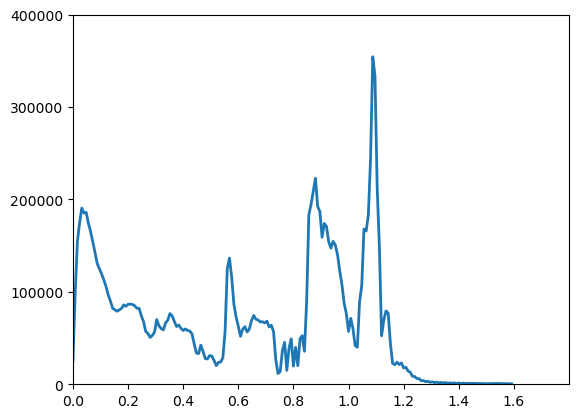

In [9]:
# plot
data=np.array(vdos.totVDoS[0])
fig, ax = plt.subplots()
ax.plot(vdos.tau, data, linewidth = 2.0)
ax.set(xlim=(0, 1.8), xticks=np.arange(0,1.8,0.2),
       ylim=(0, 400000.0), yticks=np.arange(0,400001,100000))
plt.show()

In [10]:
totMass = 0.0
for i in range(vdos.nRes):
    totMass += vdos.residueList.residues[i].resMass
averMass = totMass / vdos.nRes
averInertia = vdos.residueList.inertia[0:3]
averLogInertia = vdos.residueList.logInertia[0:3]
averRotBondCount = 0
for i in range(vdos.nRes):
    averRotBondCount += vdos.residueList.residues[i].nRotBonds
averRotBondCount /= vdos.nRes
averRotBondInertia = vdos.residueList.rotBondInertia / averRotBondCount
averLogRotBondInertia = vdos.residueList.logRotBondInertia / averRotBondCount

outFile = open("residueProperties.dat","w")
outFile.write("#Average Mass (g/mol):\n%20.6e\n" % averMass)
outFile.write("#Average Inertia (g/mol*A^2):\n%20.6e %20.6e %20.6e\n" % (averInertia[0],averInertia[1],averInertia[2]))
outFile.write("#Average Log(Inertia):\n%20.6e %20.6e %20.6e\n" % (averLogInertia[0],averLogInertia[1],averLogInertia[2]))
outFile.write("#Average Rotatable Bond Inertia (g/mol*A^2): (%d)\n%20.6e\n" % (averRotBondCount,averRotBondInertia))
outFile.write("#Average Rotatable Bond Log(Inertia): (%d)\n%20.6e\n" % (averRotBondCount,averLogRotBondInertia))
outFile.close()

In [12]:
outFile = open("corr.dat","w")
outFile.write("%-20s %-20s %-20s %-20s %-20s %-20s %-20s %-20s %-20s\n" % ("#Time (ps)","Translation x","Translation y","Translation z","Rotation x","Rotation y","Rotation z","Rotatable Bonds","Total"))
for i in range(vdos.nCorr):
    outFile.write("%-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e\n" % (vdos.tau[i],vdos.trVACF[0][0][i],vdos.trVACF[0][1][i],vdos.trVACF[0][2][i],vdos.rotVACF[0][0][i],vdos.rotVACF[0][1][i],vdos.rotVACF[0][2][i],vdos.rotBondVACF[0][i],vdos.totVACF[0][i]))
outFile.close()

In [13]:
outFile = open("vdos.dat","w")
outFile.write("%-20s %-20s %-20s %-20s %-20s %-20s %-20s %-20s %-20s\n" % ("#Wavenumber (cm^-1)","Translation x","Translation y","Translation z","Rotation x","Rotation y","Rotation z","Rotatable Bonds","Total"))
for i in range(vdos.nCorr):
    outFile.write("%-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e %-20.6e\n" % (vdos.wavenumber[i],vdos.trVDoS[0][0][i],vdos.trVDoS[0][1][i],vdos.trVDoS[0][2][i],vdos.rotVDoS[0][0][i],vdos.rotVDoS[0][1][i],vdos.rotVDoS[0][2][i],vdos.rotBondVDoS[0][i],vdos.totVDoS[0][i]))
outFile.close()